# 01 — Temporal EDA: does Avazu actually drift?

Before measuring calibration decay, verify that the temporal axis carries real signal:

1. **Daily volume & daily CTR** — is the base rate itself moving day to day?
2. **Hourly CTR** — intraday seasonality that per-hour-block ECE slices will inherit.
3. **Per-day cardinality of key categorical features** — new campaigns / sites / devices
   appearing over time is the mechanism behind covariate drift.
4. *(optional)* **Unseen-category rate** — fraction of a day's feature values never seen on
   any earlier day; a direct drift snapshot.

Requires `bash data/download.sh` to have populated `data/parquet/day=DD/`.
Reads only the columns it needs, one day-partition at a time — never the raw CSV.

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd

PARQUET_DIR = os.path.join("..", "data", "parquet")

day_dirs = sorted(glob.glob(os.path.join(PARQUET_DIR, "day=*")))
days = [int(os.path.basename(d).split("=")[1]) for d in day_dirs]
assert day_dirs, f"No partitions under {PARQUET_DIR} — run `bash data/download.sh` first."
print(f"{len(day_dirs)} day partitions: {days}")


def read_day(day_dir, columns):
    """Read one day partition, only the requested columns."""
    parts = sorted(glob.glob(os.path.join(day_dir, "*.parquet")))
    return pd.concat(
        (pd.read_parquet(p, columns=columns) for p in parts), ignore_index=True
    )

10 day partitions: [21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


## 1. Daily impressions and daily CTR

In [2]:
rows = []
for d, ddir in zip(days, day_dirs):
    clicks = read_day(ddir, ["click"])["click"]
    rows.append({"day": d, "impressions": len(clicks), "ctr": clicks.mean()})
daily = pd.DataFrame(rows).set_index("day")
daily["ctr_pct"] = 100 * daily["ctr"]
daily

,impressions,ctr,ctr_pct
day,,,
21,4122995,0.174198,17.419813
22,5337126,0.157167,15.716698
23,3870752,0.182190,18.218966
24,3335302,0.174716,17.471581
25,3363122,0.182402,18.240195
26,3835892,0.183049,18.304895
27,3225010,0.181594,18.159417
28,5287222,0.152182,15.218237
29,3832608,0.156562,15.656206


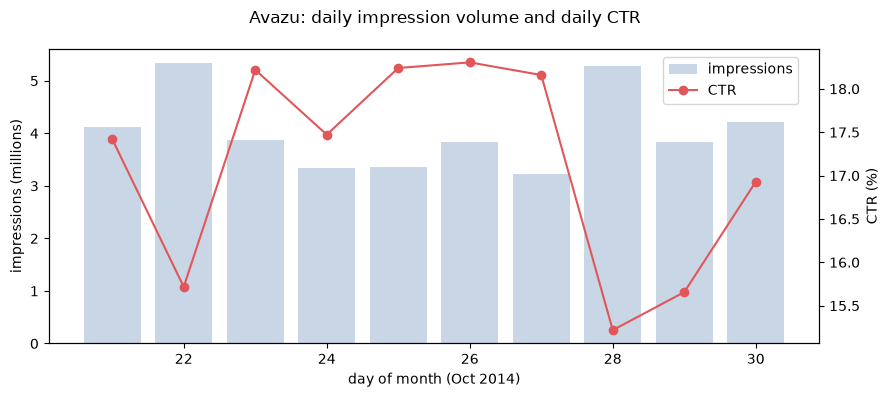

In [3]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(daily.index, daily["impressions"] / 1e6, color="#c8d6e5", label="impressions")
ax1.set_xlabel("day of month (Oct 2014)")
ax1.set_ylabel("impressions (millions)")

ax2 = ax1.twinx()
ax2.plot(daily.index, daily["ctr_pct"], "o-", color="#e15759", label="CTR")
ax2.set_ylabel("CTR (%)")

fig.suptitle("Avazu: daily impression volume and daily CTR")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
fig.tight_layout()
plt.show()

# If daily CTR moves visibly, a frozen model's probability *scale* is chasing a moving
# target — the premise behind H2/H3.

## 2. Hourly CTR across the full 10 days

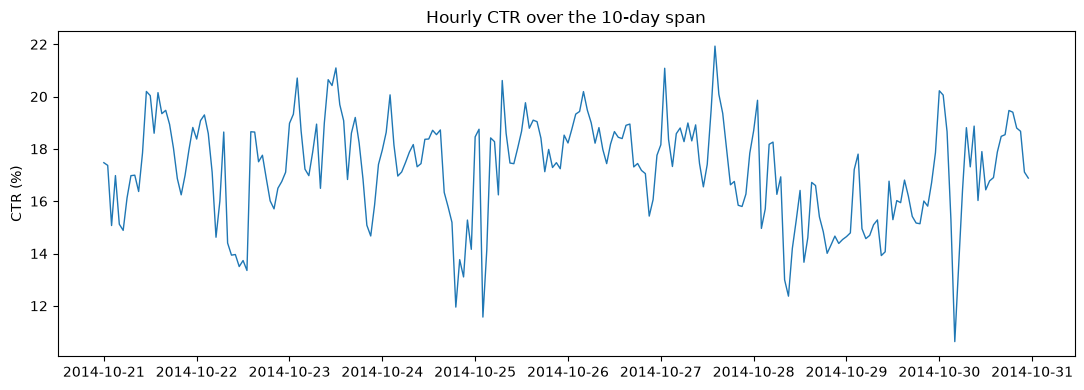

In [4]:
hourly_parts = []
for ddir in day_dirs:
    df = read_day(ddir, ["click", "hour"])
    g = df.groupby("hour")["click"].agg(["size", "mean"])
    hourly_parts.append(g)
hourly = pd.concat(hourly_parts).sort_index()

# hour is YYMMDDHH -> build a real timestamp for the x-axis
ts = pd.to_datetime(hourly.index.astype(str), format="%y%m%d%H")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts, 100 * hourly["mean"], lw=1)
ax.set_ylabel("CTR (%)")
ax.set_title("Hourly CTR over the 10-day span")
fig.tight_layout()
plt.show()

## 3. Per-day cardinality of key categorical features

Rising or churning cardinality (especially `device_ip`, `device_id`, `site_id`, `app_id`)
means the categorical vocabulary itself is non-stationary — embeddings trained on days 1–8
will face values on day 10 they have never seen.

In [5]:
CAT_FEATURES = [
    "site_id", "site_domain", "app_id", "app_domain",
    "device_id", "device_ip", "device_model", "C14", "C17", "C20",
]

card_rows = []
for d, ddir in zip(days, day_dirs):
    df = read_day(ddir, CAT_FEATURES)
    card_rows.append({"day": d, **{c: df[c].nunique() for c in CAT_FEATURES}})
    del df
cardinality = pd.DataFrame(card_rows).set_index("day")
cardinality

,site_id,site_domain,app_id,app_domain,device_id,device_ip,device_model,C14,C17,C20
day,,,,,,,,,,
21,2865,3394,4154,287,368962,1078153,6098,785,193,168
22,3107,3811,4182,315,432220,1152737,6071,878,199,166
23,3041,3784,3637,248,337970,920644,5687,931,203,164
24,2861,3486,3270,208,225844,783597,5449,965,207,161
25,2998,3725,3238,220,265747,811689,5404,786,168,159
26,3172,4061,3482,212,303006,938095,5556,915,176,162
27,3050,4014,3211,212,297757,818442,5497,1114,199,161
28,3196,4001,3817,221,401023,1210060,5834,1407,219,166
29,2893,3613,3019,188,361400,970835,5622,1305,219,166


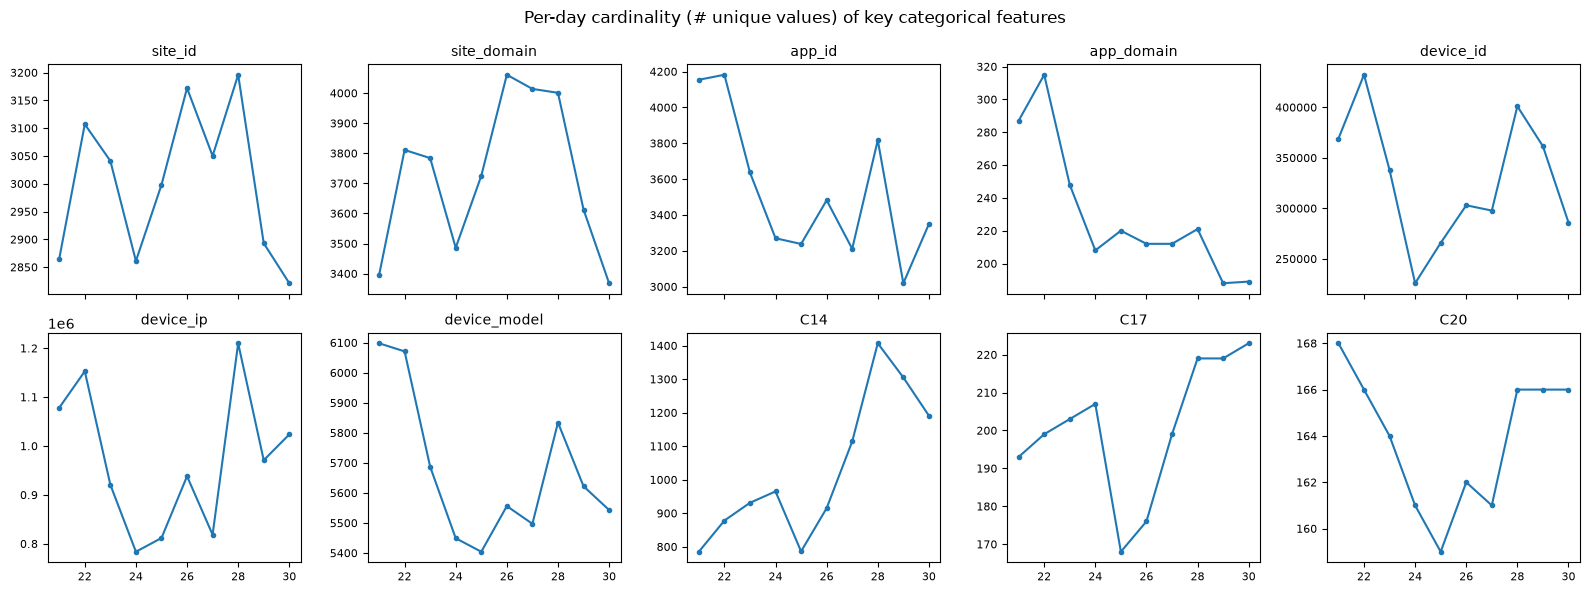

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=True)
for ax, col in zip(axes.ravel(), CAT_FEATURES):
    ax.plot(cardinality.index, cardinality[col], "o-", ms=3)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
fig.suptitle("Per-day cardinality (# unique values) of key categorical features")
fig.tight_layout()
plt.show()

## 4. (Optional) Unseen-category rate: share of day-*d* values absent from days < *d*

The most direct covariate-drift snapshot. Memory-heavy for `device_ip`; start with
`site_id`/`app_id` and skip this cell on low-RAM machines.

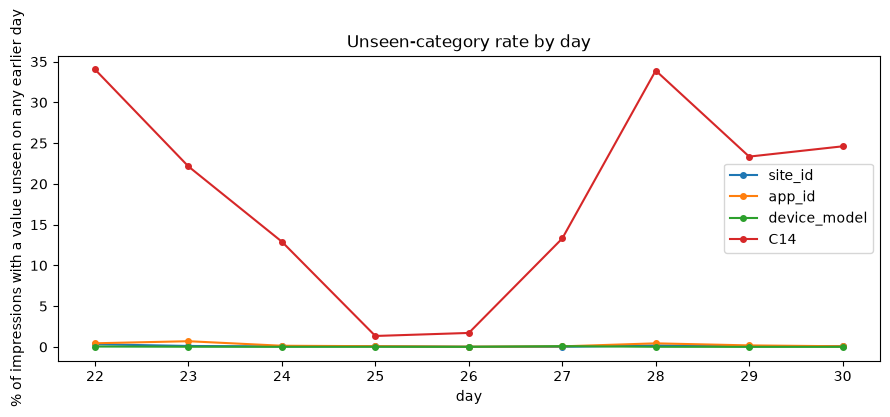

In [7]:
PROBE_FEATURES = ["site_id", "app_id", "device_model", "C14"]

seen = {c: set() for c in PROBE_FEATURES}
unseen_rows = []
for d, ddir in zip(days, day_dirs):
    df = read_day(ddir, PROBE_FEATURES)
    row = {"day": d}
    for c in PROBE_FEATURES:
        vals = df[c]
        if seen[c]:
            row[c] = (~vals.isin(seen[c])).mean()  # impression-weighted unseen rate
        else:
            row[c] = float("nan")  # first day has no history
        seen[c].update(vals.unique())
    unseen_rows.append(row)
    del df
unseen = pd.DataFrame(unseen_rows).set_index("day")

ax = (100 * unseen).plot(figsize=(9, 4), marker="o", ms=4)
ax.set_ylabel("% of impressions with a value unseen on any earlier day")
ax.set_title("Unseen-category rate by day")
plt.tight_layout()
plt.show()

---
**Takeaways (fill in after running):**

- Daily CTR range: …
- Volume anomalies / weekday-weekend pattern: …
- Fastest-churning features: …
- Implication for the day 1–8 / 9 / 10 split: …